# Model Training

## Student Mental Health Analyzer

---

## Objective

The objective of this notebook is to train and evaluate multiple machine learning models for predicting student depression.

The models will be compared using multiple evaluation metrics to identify the most effective classifier.

The trained model selected in this notebook will later be used for:

- Depression prediction
- Wellness score generation
- Personalized recommendation system

In [25]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [26]:
X_train = pd.read_csv("../data/final/X_train.csv")
X_test = pd.read_csv("../data/final/X_test.csv")

y_train = pd.read_csv("../data/final/y_train.csv").squeeze()

y_test = pd.read_csv("../data/final/y_test.csv").squeeze()

In [27]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (22249, 38)
Testing Features : (5563, 38)
Training Labels : (22249,)
Testing Labels : (5563,)


In [28]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [29]:
print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.5861944993708431


In [30]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [31]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81      2302
           1       0.85      0.89      0.87      3261

    accuracy                           0.85      5563
   macro avg       0.85      0.84      0.84      5563
weighted avg       0.85      0.85      0.85      5563



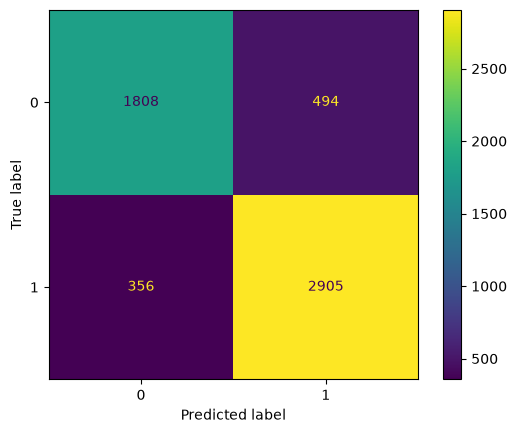

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.show()

In [33]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [34]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    random_state=42,

    eval_metric="logloss"

)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [36]:
def evaluate_model(model_name, y_true, y_pred):

    return {

        "Model": model_name,

        "Accuracy": accuracy_score(y_true,y_pred),

        "Precision": precision_score(y_true,y_pred),

        "Recall": recall_score(y_true,y_pred),

        "F1 Score": f1_score(y_true,y_pred),

        "ROC AUC": roc_auc_score(y_true,y_pred)

    }

In [37]:
results=[]

results.append(
    evaluate_model(
        "Baseline",
        y_test,
        baseline_pred
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.586194,0.586194,1.000000,0.739121,0.500000
1,Logistic Regression,0.847205,0.854663,0.890831,0.872372,0.838118
2,Decision Tree,0.774402,0.809186,0.804968,0.807071,0.768036
3,Random Forest,0.842891,0.853630,0.883471,0.868294,0.834438
4,XGBoost,0.836599,0.851675,0.873352,0.862377,0.828943


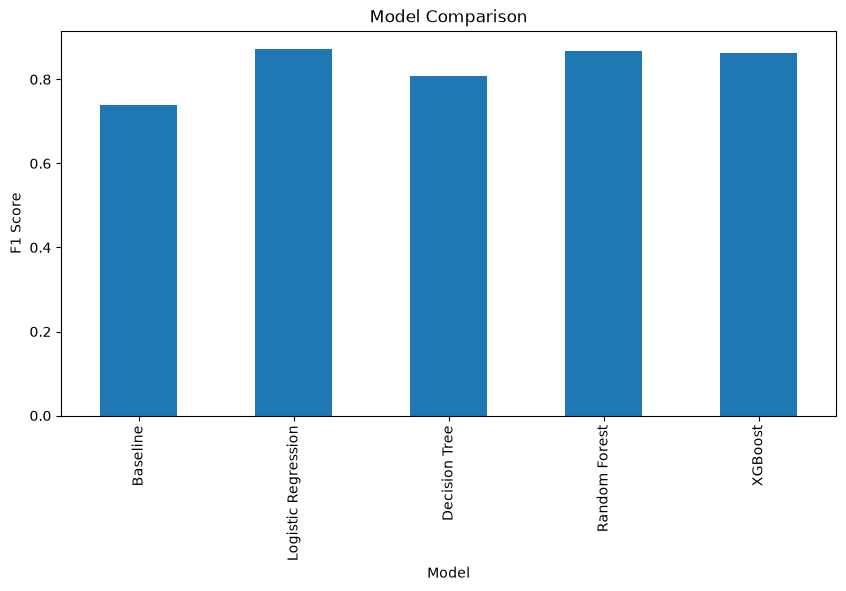

In [38]:
results_df.set_index("Model")["F1 Score"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("F1 Score")

plt.title("Model Comparison")

plt.show()

In [39]:
best_model = results_df.sort_values(

    "F1 Score",

    ascending=False

).iloc[0]

best_model

Model        Logistic Regression
Accuracy                0.847205
Precision               0.854663
Recall                  0.890831
F1 Score                0.872372
ROC AUC                 0.838118
Name: 1, dtype: object

In [40]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(lr, "../models/best_model.pkl")

print("✅ Best model saved successfully.")

✅ Best model saved successfully.


In [41]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Absolute Coefficient
7,Have you ever had suicidal thoughts ?,2.498136,2.498136
2,Academic Pressure,0.857620,0.857620
36,Degree_Others,0.704759,0.704759
9,Financial Stress,0.556725,0.556725
6,Dietary Habits,-0.544967,0.544967
23,Degree_LLM,0.532322,0.532322
21,Degree_BSc,0.350154,0.350154
25,Degree_M.Ed,0.338703,0.338703
31,Degree_MCA,0.317404,0.317404
22,Degree_LLB,0.298838,0.298838


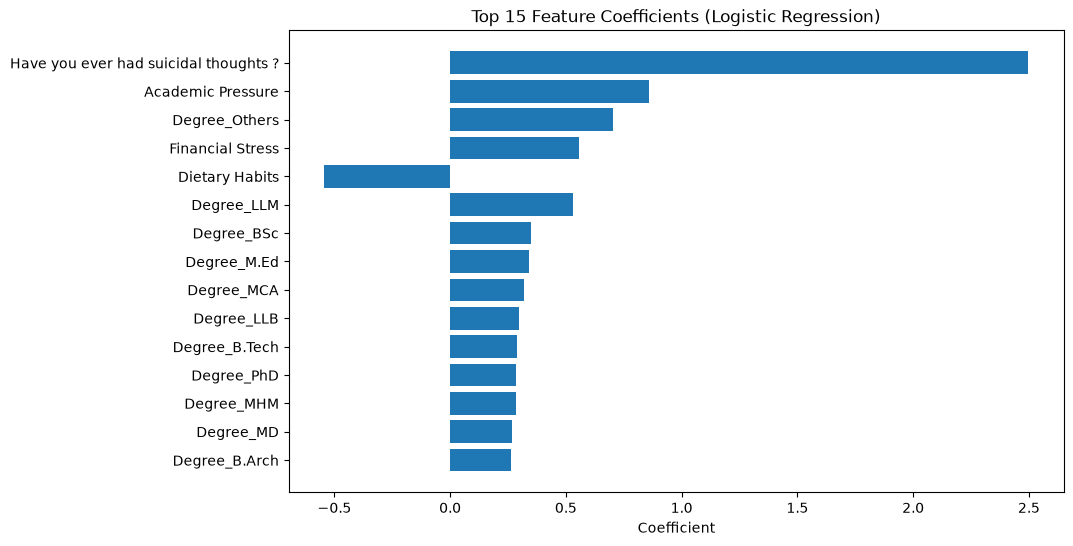

In [42]:
import matplotlib.pyplot as plt

top_features = coef_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top 15 Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()
plt.show()